# Векторизация текста


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from gensim.models.word2vec import Word2Vec
from gensim.models.doc2vec import TaggedDocument, Doc2Vec
import gensim.downloader as api
from scipy.spatial.distance import cdist
np.random.seed(42)

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)

sns.set_palette("husl")


Для демонстрации используем датасет **20 Newsgroups** - уже немного знакомый нам набор данных для задач текстовой классификации. Он содержит около 20,000 новостных сообщений, разделенных на 20 категорий, хорошо сбалансирован.


In [2]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

print("Загрузка данных 20 Newsgroups...")
newsgroups_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

print(f"Обучающая выборка: {len(newsgroups_train.data)} документов")
print(f"Тестовая выборка: {len(newsgroups_test.data)} документов")
print(f"Количество категорий: {len(categories)}")
print(f"\nКатегории: {categories}")


Загрузка данных 20 Newsgroups...
Обучающая выборка: 2257 документов
Тестовая выборка: 1502 документов
Количество категорий: 4

Категории: ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']


## Предобработка текста

Текст требует специальной предобработки перед использованием в моделях машинного обучения. Основные шаги:

1. **Токенизация** - разбиение текста на отдельные слова (токены)
2. **Нормализация** - приведение к нижнему регистру
3. **Удаление стоп-слов** - удаление часто встречающихся, но не несущих смысловой нагрузки слов (или мата, например)
4. **Лемматизация/Стемминг** - приведение слов к их базовой форме

Лемматизация — процесс приведения слова к его нормальной форме (лемме):
- для существительных — именительный падеж, единственное число;
- для прилагательных — именительный падеж, единственное число, мужской род; 
- для глаголов, причастий, деепричастий — глагол в инфинитиве.
Для лемматизации на русском языке есть библиотека pymorphy3.

Stemming – это процесс нахождения основы слова. В результате применения данной процедуры однокоренные слова, как правило, преобразуются к одинаковому виду. 
Snowball – фрэймворк для написания алгоритмов стемминга. Алгоритмы стемминга отличаются для разных языков и используют знания о конкретном языке – списки окончаний для разных чистей речи, разных склонений и т.д. Пример алгоритма для русского языка – Russian stemming.


In [3]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

example_text = newsgroups_train.data[0]
print("Исходный текст (первые 300 символов):")
print(example_text[:300])

Исходный текст (первые 300 символов):
Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.


In [4]:
text = example_text.lower()
text = re.sub(r'[^a-zA-Z\s]', '', text)
tokens = word_tokenize(text)
tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
print(tokens)

['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'files', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'files', 'please', 'email', 'response', 'correct', 'group', 'thanks', 'advance', 'michael']


In [5]:
tokens = [lemmatizer.lemmatize(word) for word in tokens]
print(tokens)

['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'file', 'please', 'email', 'response', 'correct', 'group', 'thanks', 'advance', 'michael']


In [6]:
tokens = [stemmer.stem(word) for word in tokens]
print(tokens)

['anyon', 'know', 'good', 'way', 'standard', 'applicationpd', 'util', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'convert', 'hpgl', 'plotter', 'file', 'pleas', 'email', 'respons', 'correct', 'group', 'thank', 'advanc', 'michael']


In [7]:

def preprocess_text(text: str, use_lemmatization: bool = True) -> str:
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    else:
        tokens = [stemmer.stem(word) for word in tokens]
    
    return ' '.join(tokens)

print("После предобработки:")
processed = preprocess_text(example_text)
print(processed[:300])


После предобработки:
anyone know good way standard applicationpd utility convert tifimgtga file laserjet iii format would also like converting hpgl plotter file please email response correct group thanks advance michael


##  Векторизация текста
ML модели работают с числовыми данными, поэтому текст нужно преобразовать в числовые векторы. Рассмотрим несколько основных подходов:

**Bag-of-Words** - простейший способ представления текста. Каждый документ в нем представляется как вектор, где каждая позиция соответствует определенному слову из словаря, а значение - частоте появления этого слова в документе.
Это наиболее простой метод, но он приводит к потере информации о порядке слов и приводит к очень разреженным векторам.



In [8]:
print("Предобработка текстов...")
X_train_processed = [preprocess_text(text) for text in newsgroups_train.data[:1000]]
X_test_processed = [preprocess_text(text) for text in newsgroups_test.data[:500]]

print(f"Обработано {len(X_train_processed)} обучающих и {len(X_test_processed)} тестовых документов")


Предобработка текстов...
Обработано 1000 обучающих и 500 тестовых документов


In [9]:
bow_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95
)

print("Создание Bag-of-Words представления...")
X_train_bow = bow_vectorizer.fit_transform(X_train_processed)
X_test_bow = bow_vectorizer.transform(X_test_processed)

print(f"Размерность обучающей выборки: {X_train_bow.shape}")
print(f"Размерность тестовой выборки: {X_test_bow.shape}")
print(f"Размер словаря: {len(bow_vectorizer.vocabulary_)}")

print(f"\nПримеры слов из словаря (первые 20):")
print(list(bow_vectorizer.vocabulary_.keys())[:20])


Создание Bag-of-Words представления...
Размерность обучающей выборки: (1000, 5000)
Размерность тестовой выборки: (500, 5000)
Размер словаря: 5000

Примеры слов из словаря (первые 20):
['anyone', 'know', 'good', 'way', 'standard', 'utility', 'convert', 'file', 'iii', 'format', 'would', 'also', 'like', 'converting', 'plotter', 'please', 'email', 'response', 'correct', 'group']


In [10]:
doc_vector = X_train_bow[0].toarray()[0]
non_zero_indices = np.where(doc_vector > 0)[0]

print(f"Документ содержит {len(non_zero_indices)} уникальных слов из словаря")
print(f"Общее количество слов в документе: {doc_vector.sum()}")

feature_names = bow_vectorizer.get_feature_names_out()
top_words_idx = np.argsort(doc_vector)[-10:][::-1]
print("\nТоп-10 слов в документе:")
for idx in top_words_idx:
    if doc_vector[idx] > 0:
        print(f"  {feature_names[idx]}: {int(doc_vector[idx])}")


Документ содержит 23 уникальных слов из словаря
Общее количество слов в документе: 24

Топ-10 слов в документе:
  file: 2
  way: 1
  plotter: 1
  would: 1
  michael: 1
  standard: 1
  response: 1
  please: 1
  thanks: 1
  utility: 1


**Задание**:  Постройте bag-of-words для слов без лемматизации и стемминга (а также только с лемматизацией). Как их отсутствие повлияет на размеры словаря (попробуйте не обрезать) и встречаемость слов?

In [11]:
def preprocess_text_mode(text: str, mode: str = "none") -> str:
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    if mode == "lemma":
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    elif mode == "stem":
        tokens = [stemmer.stem(word) for word in tokens]
    elif mode == "none":
        pass
    else:
        raise ValueError("ввести 'none', 'lemma' or 'stem'")
    
    return " ".join(tokens)

In [12]:
texts_raw = newsgroups_train.data[:1000]

processed_none = [preprocess_text_mode(text, mode="none") for text in texts_raw]
processed_lemma = [preprocess_text_mode(text, mode="lemma") for text in texts_raw]
processed_stem = [preprocess_text_mode(text, mode="stem") for text in texts_raw]

vectorizers = {
    "без lemma/stem": CountVectorizer(),
    "lemmatization": CountVectorizer(),
    "stemming": CountVectorizer()
}

X_bow_none = vectorizers["без lemma/stem"].fit_transform(processed_none)
X_bow_lemma = vectorizers["lemmatization"].fit_transform(processed_lemma)
X_bow_stem = vectorizers["stemming"].fit_transform(processed_stem)

bow_compare = pd.DataFrame({
    "variant": ["без lemma/stem", "lemmatization", "stemming"],
    "vocab_size": [
        len(vectorizers["без lemma/stem"].vocabulary_),
        len(vectorizers["lemmatization"].vocabulary_),
        len(vectorizers["stemming"].vocabulary_)
    ],
    "matrix_shape": [
        X_bow_none.shape,
        X_bow_lemma.shape,
        X_bow_stem.shape
    ],
    "non_zero_values": [
        X_bow_none.nnz,
        X_bow_lemma.nnz,
        X_bow_stem.nnz
    ]
})

bow_compare

,variant,vocab_size,matrix_shape,non_zero_values
0,без lemma/stem,18127,"(1000, 18127)",75108
1,lemmatization,16367,"(1000, 16367)",72722
2,stemming,12982,"(1000, 12982)",69592


In [13]:
def get_top_words(X_bow, vectorizer, top_n=15):
    word_counts = np.asarray(X_bow.sum(axis=0)).ravel()
    feature_names = vectorizer.get_feature_names_out()
    top_idx = np.argsort(word_counts)[-top_n:][::-1]
    
    return pd.DataFrame({
        "word": feature_names[top_idx],
        "count": word_counts[top_idx].astype(int)
    })


top_none = get_top_words(X_bow_none, vectorizers["без lemma/stem"])
top_lemma = get_top_words(X_bow_lemma, vectorizers["lemmatization"])
top_stem = get_top_words(X_bow_stem, vectorizers["stemming"])

print("Без lemma/stem")
display(top_none)

print("Lemmatization")
display(top_lemma)

print("Stemming")
display(top_stem)

Без lemma/stem


,word,count
0,would,676
1,one,672
2,god,655
3,people,476
4,dont,453
5,also,417
6,know,369
7,think,360
8,image,353
9,like,341


Lemmatization


,word,count
0,god,780
1,one,735
2,would,676
3,image,489
4,people,486
5,dont,453
6,also,417
7,know,402
8,time,387
9,think,370


Stemming


,word,count
0,god,780
1,one,741
2,would,676
3,use,605
4,imag,513
5,peopl,486
6,dont,453
7,know,430
8,think,428
9,say,428


Видно, что отсутствие лемматизации и стемминга приводит к самому большому размеру словаря: `18127` признаков. После лемматизации размер словаря уменьшился до `16367`, а после стемминга — до `12982`.

### TF-IDF (Term Frequency-Inverse Document Frequency)

**TF-IDF** - более продвинутый способ векторизации, который учитывает не только частоту слова в документе, но и его важность в корпусе.

- **TF (Term Frequency)**: частота слова в документе.

- **IDF (Inverse Document Frequency)**: обратная частота документа - мера того, насколько редким является слово в корпусе: 
$\text{IDF}(t) = \log\frac{N}{\text{df}(t)}$, где $N$ - общее количество документов, $\text{df}(t)$ - количество документов, содержащих термин $t$.

**Формула:**
$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$



In [14]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_processed)
X_test_tfidf = tfidf_vectorizer.transform(X_test_processed)

print(f"Размерность обучающей выборки: {X_train_tfidf.shape}")
print(f"Размерность тестовой выборки: {X_test_tfidf.shape}")

feature_names = tfidf_vectorizer.get_feature_names_out()
idf_values = tfidf_vectorizer.idf_

top_idf_idx = np.argsort(idf_values)[-20:][::-1]
print("\nТоп-20 слов с наибольшим IDF:")
for idx in top_idf_idx:
    print(f"  {feature_names[idx]}: IDF = {idf_values[idx]:.3f}")


Размерность обучающей выборки: (1000, 5000)
Размерность тестовой выборки: (500, 5000)

Топ-20 слов с наибольшим IDF:
  hail: IDF = 6.810
  academic: IDF = 6.810
  godhead: IDF = 6.810
  abc: IDF = 6.810
  god truth: IDF = 6.810
  hath: IDF = 6.810
  xloadimage: IDF = 6.810
  acidic: IDF = 6.810
  serial port: IDF = 6.810
  septuagint: IDF = 6.810
  worshipping: IDF = 6.810
  worldview: IDF = 6.810
  hernia: IDF = 6.810
  hicolor: IDF = 6.810
  cause effect: IDF = 6.810
  catholic theology: IDF = 6.810
  shalala said: IDF = 6.810
  shalala: IDF = 6.810
  showcase: IDF = 6.810
  silicon graphic: IDF = 6.810


In [15]:
mask = [i for i, el in enumerate(X_train_processed) if el.find("hicolor") > -1 ]

In [16]:
X_train_processed[123]

'cut limit azt efficacy suggest using drug either sequentially drug kind aid treatment cocktail combining number drug fight virus treating people azt alone doesnt happen real world anymore said mark jacobson university californiasan francisco also recent finding indicating hiv replicates rapidly lymph node infection physician may begin pushing even harder early treatment hivinfected patient new infectious disease push american medical news vol center disease control launch worldwide network track spread infectious disease detect drugresistant new strain time help prevent spread network expected cost million million essential part clinton administration health reform plan according cdc outside expert plan require cdc enhance surveillance disease united state establish facility across world track disease april nih plan begin aid drug trial earlier stage nature vol macilwain colin hicnet medical newsletter page volume number april national institute health announced start treating hivposi

Задание: Поиграйте с настройками для TF-IDF. Что будет, если не использовать idf (use_idf=False), как изменятся эмбеддинги? Что будет, если использовать sublinear_tf=True? Что будет ,если не нормализовать векторы? Можете сравнивать результаты через визуализации или численные характеристики.

In [17]:
configs = {
    "default": {},
    "use_idf=False": {"use_idf": False},
    "sublinear_tf=True": {"sublinear_tf": True},
    "norm=None": {"norm": None},
}

rows = []

for name, params in configs.items():
    vectorizer = TfidfVectorizer(
        max_features=5000,
        min_df=2,
        max_df=0.95,
        ngram_range=(1, 2),
        **params
    )
    
    X_vec = vectorizer.fit_transform(X_train_processed)
    norms = np.sqrt(X_vec.multiply(X_vec).sum(axis=1)).A1
    
    rows.append({
        "variant": name,
        "shape": X_vec.shape,
        "non_zero": X_vec.nnz,
        "mean_norm": norms.mean(),
        "max_value": X_vec.max()
    })

tfidf_compare = pd.DataFrame(rows)
tfidf_compare

,variant,shape,non_zero,mean_norm,max_value
0,default,"(1000, 5000)",61932,0.97200,1.000000
1,use_idf=False,"(1000, 5000)",61932,0.97200,1.000000
2,sublinear_tf=True,"(1000, 5000)",61932,0.97200,1.000000
3,norm=None,"(1000, 5000)",61932,53.15432,1121.233937


**Выводы:**

Настройки use_idf=False, sublinear_tf=True и norm=None не меняют размерность матрицы и число ненулевых элементов, потому что словарь остается тем же. Они меняют только значения весов внутри матрицы.

При norm=None нормы векторов становятся намного больше. В этом случае длина вектора начинает зависеть от длины документа и частот слов. Это видно по `mean_norm = 53.15` и `max_value = 1121.23`.

##  Эмбеддинги слов

**Эмбеддинги слов** (word embeddings) — плотные векторы фиксированной размерности, в которых семантически близкие слова оказываются близки в пространстве. В отличие от Bag-of-Words и TF-IDF это распределённое представление (distributed representation): векторы плотные, а не разреженные, и кодируют контекстное употребление слова.

Подробнее см. в [word_embeddings.md](word_embeddings.md).

### Word2Vec

**Word2Vec** учит векторные представления слов, предсказывая контекст по слову или слово по контексту. Варианты:

- **Skip-gram**: по центральному слову предсказываем слова в окне (контекст).
- **CBOW** (Continuous Bag of Words): по сумме векторов контекста предсказываем центральное слово.

Цель обучения — максимизация правдоподобия; на практике используют **negative sampling** (несколько случайных «негативных» слов вместо полного softmax по словарю). 

Основные параметры: `vector_size` (размерность), `window` (размер окна), `min_count`, `sg` (1 = skip-gram, 0 = CBOW), `negative` (число негативных примеров), `epochs`.

Обучим такую модель.

In [18]:
sentences = [text.split() for text in X_train_processed[:1500]]
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    negative=5,
    epochs=10,
    seed=42,
)
embeddings_dict = {w: w2v_model.wv[w] for w in w2v_model.wv.index_to_key}
word_to_idx = {w: i for i, w in enumerate(w2v_model.wv.index_to_key)}

print("Примеры ближайших слов (most_similar):")
for word in ["computer", "medical", "god", "graphics", "cat", "rain", "cup"]:
    if word in w2v_model.wv:
        sim = w2v_model.wv.most_similar(word, topn=6)
        print(f"  {word}: {[t[0] for t in sim]}")


Примеры ближайших слов (most_similar):
  computer: ['graphic', 'modeling', 'idl', 'visualization', 'silicon', 'project']
  medical: ['newsletter', 'hicnet', 'april', 'journal', 'page', 'volume']
  god: ['sinner', 'fear', 'gift', 'peace', 'grace', 'justice']
  cat: ['putting', 'chiropractor', 'throat', 'seemed', 'ingredient', 'spanking']
  cup: ['paid', 'wage', 'arrived', 'filled', 'forever', 'iraqi']


### Doc2Vec

**Doc2Vec** даёт векторное представление целого документа (или предложения), а не среднее векторов слов. 
Алгоритмы:
- **PV-DM** (аналог CBOW для документов). Также обучается предсказание центрального слова, но на вход подается еще и вектор документа (paragraph vector). Этот вектор участвует в предсказании вместе с контекстными словами
- **PV-DBOW** (аналог skip-gram). Вход — список `TaggedDocument`: список слов + уникальный id документа. Модель учится предсказывать слова из этого документа (несколько случайных), обучается только paragraph vector.

Для документа, которого не было в обучающей выборке, готового вектора нет. Тогда делают inference:
- веса модели (векторы cлов и т.д.) фиксируют
- вводят новый вектор только для этого документа и подбирают его градиентным спуском так, чтобы по этому вектору (и при необходимости контексту) хорошо предсказывались слова документа.
В итоге получают embedding нового документа в том же пространстве, что и у обучающих документов.


In [19]:
tagged_docs = [
    TaggedDocument(words=text.split(), tags=[i]) # чтобы обучить модель, нужно получить список слов
    for i, text in enumerate(X_train_processed[:800])
]
d2v_model = Doc2Vec(vector_size=50, min_count=2, epochs=10, seed=42, dm=1)
d2v_model.build_vocab(tagged_docs)
d2v_model.train(tagged_docs, total_examples=d2v_model.corpus_count, epochs=d2v_model.epochs)

document_dict = {}
for idx, text in enumerate(X_train_processed[:20]):
    text = text.split()
    document_dict[idx] = d2v_model.dv[idx]

document_embeddings_df = pd.DataFrame.from_dict(document_dict, orient="index")
document_embeddings_df.head()


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.033645,-0.016902,0.012913,-0.094362,0.027028,-0.013447,-0.032439,0.022029,0.022665,0.049876,...,0.014990,0.030427,0.069444,-0.025743,0.112805,0.019933,0.091779,0.056187,0.043433,-0.055793
1,-0.249877,-0.457367,-0.112992,-0.348362,0.132379,-0.062250,-0.173904,-0.107854,0.030787,0.377439,...,-0.115816,-0.109462,0.400449,0.099084,0.487656,0.210492,0.457373,0.445627,0.289731,-0.355790
2,-0.398835,-0.805068,-0.201015,-0.549054,0.209373,-0.054869,-0.268628,-0.214908,-0.019107,0.583820,...,-0.256323,-0.235689,0.610853,0.071701,0.779028,0.343654,0.803395,0.800275,0.518221,-0.635767
3,-0.055362,-0.187918,-0.059860,-0.111661,-0.001555,-0.033137,-0.051457,-0.060182,-0.019003,0.085448,...,-0.078447,-0.068739,0.123592,0.034750,0.121574,0.085276,0.146278,0.132877,0.099310,-0.109597
4,0.013737,-0.002756,0.011587,-0.015804,0.005336,-0.006752,-0.013885,0.014571,0.018285,0.005844,...,0.000492,-0.005479,-0.011015,-0.012938,0.007225,0.019289,-0.005575,0.006036,0.007087,0.017889


Найдем наиболее похожие документы на запрос (строка или слово) и выведем текст топ 3 похожих документов. Похожесть определяется косинусным расстоянием между векторами - мы можем построить расстояния между каким-то вектором и всеми из обучающего набора, минимальные расстояния будут соответствовать лучшим совпадениям. Примерно также работает RAG. Правда, чаще в поиске комбинируют поиск по эмбеддингам и текстовое расстояние с помощью алгоритма BM-25. 


In [20]:
def most_similar(vec, embeddings_df, n=5):
    # compute similarity
    doc_sim = (1-cdist(embeddings_df.values, vec, 'cosine'))

    # convert result to a date frame
    sim_df = pd.DataFrame(doc_sim, columns=["cos_sim"]).assign(
        document_id=list(embeddings_df.index)
    )

    # sort from most similar to least
    sim_df = sim_df.sort_values("cos_sim", ascending=False)
    return sim_df.head(n)


In [21]:
query = "computer graphics"

query_words = preprocess_text(query).split()
if len(query_words) == 0:
    query_words = query.split()

query_vec = d2v_model.infer_vector(query_words)

print("Query:", query)
print("\nTop-3 via d2v_model.dv.most_similar (all 800 docs):")
res_dv = d2v_model.dv.most_similar(positive=[query_vec], topn=3)
for rank, (doc_id, score) in enumerate(res_dv, start=1):
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[int(doc_id)])

print("\nTop-3 via most_similar + cdist (all 800 docs):")
document_embeddings_all_df = pd.DataFrame(
    [d2v_model.dv[i] for i in range(len(tagged_docs))],
    index=list(range(len(tagged_docs))),
)

res_cdist_df = most_similar(query_vec.reshape(1, -1), document_embeddings_all_df, n=3)
for rank, row in enumerate(res_cdist_df.itertuples(index=False), start=1):
    doc_id = int(row.document_id)
    score = float(row.cos_sim)
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[doc_id])

print("\nComparison (doc_id lists):")
print("dv.most_similar:", [int(doc_id) for doc_id, _ in res_dv])
print("cdist+df top3:", [int(doc_id) for doc_id in res_cdist_df.document_id.tolist()])


Query: computer graphics

Top-3 via d2v_model.dv.most_similar (all 800 docs):

#1 doc_id=400, cos_sim=0.9354
archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april scene generatorsgeographical datamapsdata file dems digital elevation model dems digital elevation model well cartographic data huge available spectrumxeroxcom pubmap contact lee moore webster research center xerox corp voice arpa internet moorewbstxeroxcom check also ncgiaucsbedu pubdems nfotis many file also available cdrom selled usgs scale digital line graph dlg data contains data state price call visit office menlo park reston virginia usamaps data user service division bureau census also data cdrom tso standard format derived usgs map data call info bb drdobbs march defense mapping agency cooperation counterpart agency canada australia released digital chart world dcw chart consists gigabyte reasonable quality vector data distributed four cdroms includ

### Визуализация эмбеддингов Word2Vec

Посмотрим на то, как эмбеддинги расположены в пространстве - построим 2D-проекцию векторов слов (PCA и t-SNE) по обученной модели Word2Vec.


Объясненная дисперсия PCA: 0.48112488


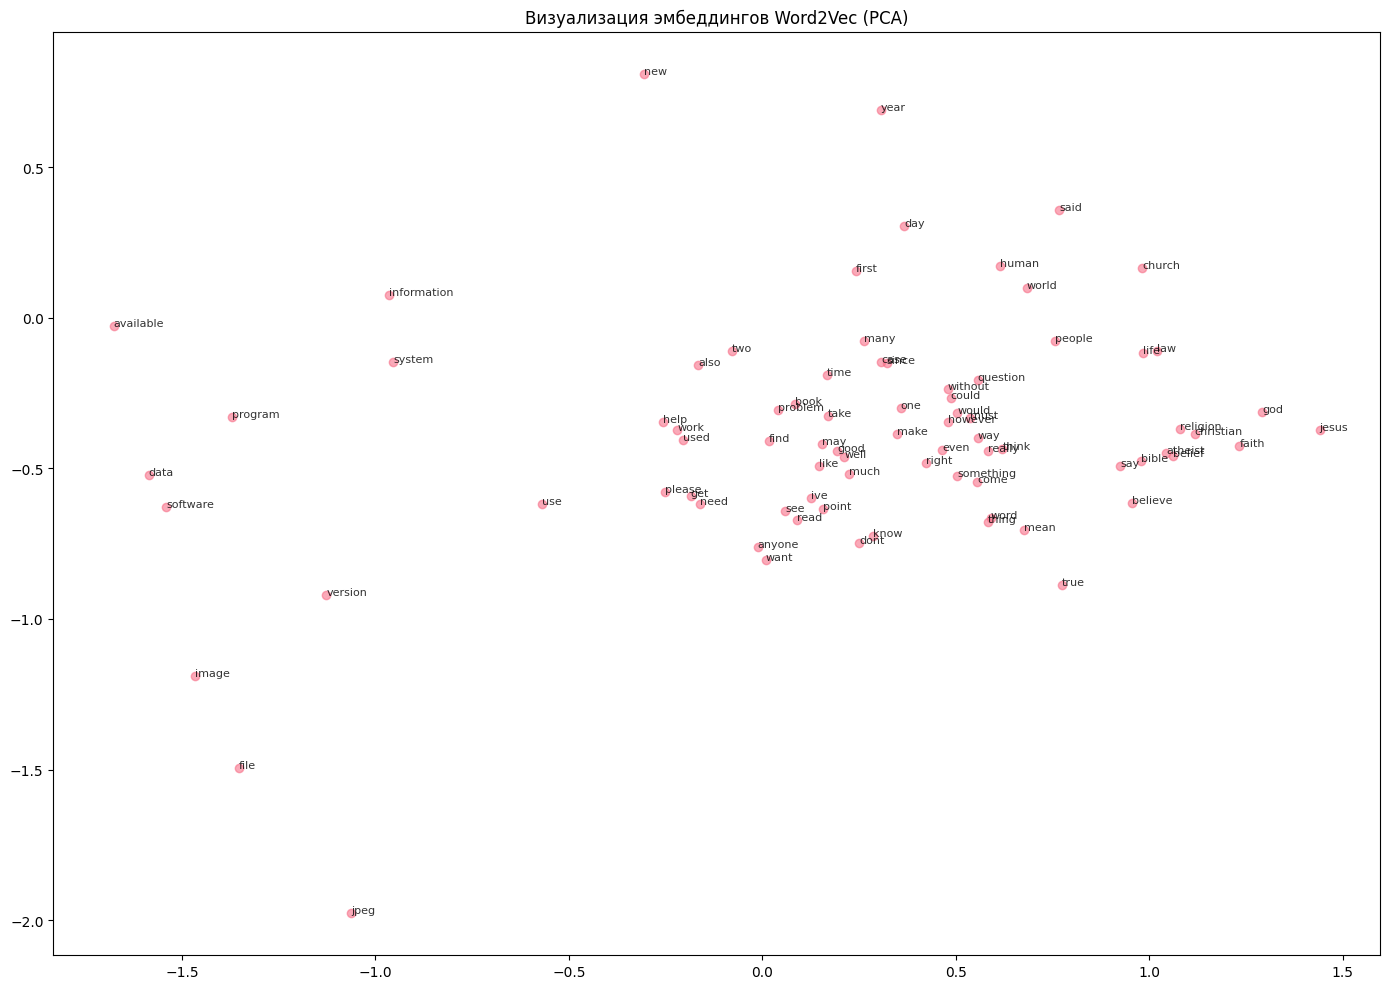

In [22]:
top_word_list = list(w2v_model.wv.index_to_key)[:80]
embeddings = np.array([w2v_model.wv[w] for w in w2v_model.wv.index_to_key]) 
embeddings = embeddings - embeddings.mean(axis=0)

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)
print("Объясненная дисперсия PCA:", pca.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(embeddings_2d[:len(top_word_list), 0], embeddings_2d[:len(top_word_list), 1], alpha=0.6)
for i, word in enumerate(top_word_list):
    ax.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Визуализация эмбеддингов Word2Vec (PCA)")
plt.tight_layout()
plt.show()


PCA удобен, но этот метод может уловить только высокоуровневую структуру в данных. Попробуем порисовать эмбеддинги с помощью t-SNE. Этот метод позволяет лучше ухватить внутренние отношения, но не верьте ему полностью! Подробнее в [гайде](https://distill.pub/2016/misread-tsne/). 

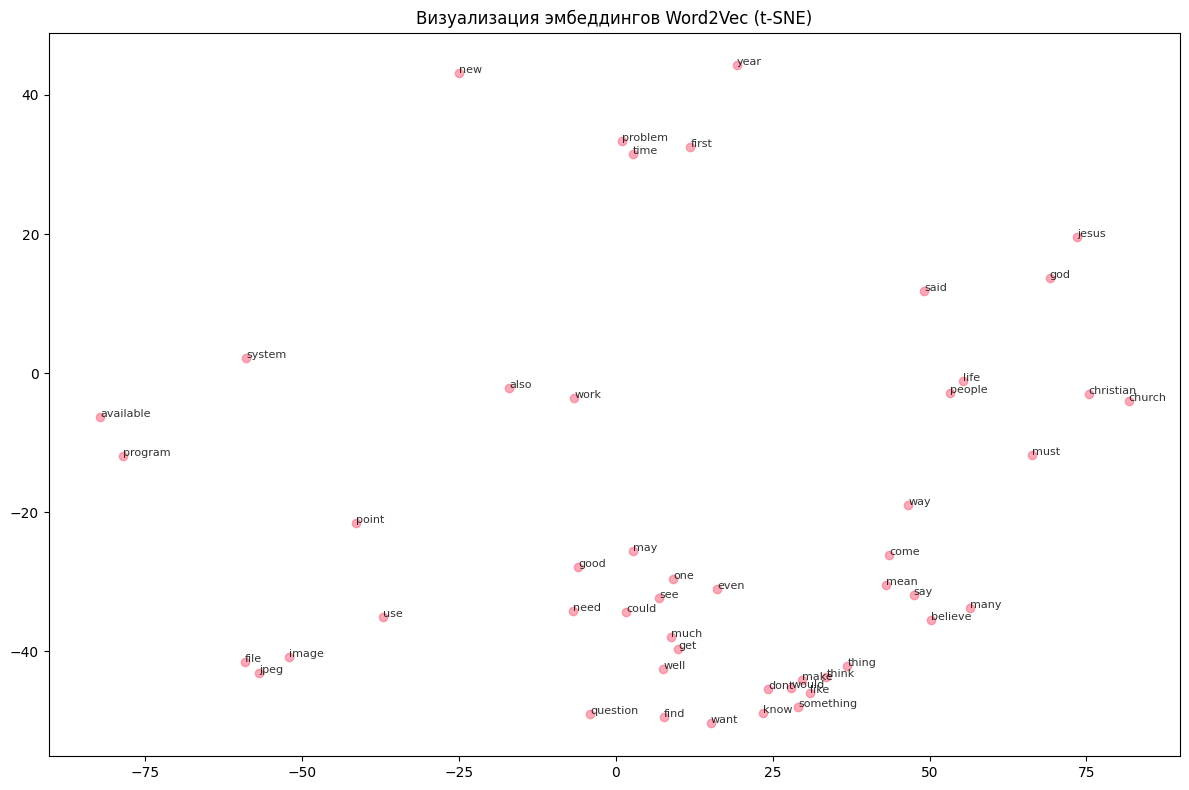

In [23]:
top_word_list_tsne = top_word_list[:50]
embeddings = np.array([w2v_model.wv[w] for w in w2v_model.wv.index_to_key]) 
embeddings = embeddings - embeddings.mean(axis=0)

tsne = TSNE(n_components=2, random_state=42, perplexity=15)
emb_tsne = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(emb_tsne[:50, 0], emb_tsne[:50, 1], alpha=0.6)
for i, word in enumerate(top_word_list_tsne):
    ax.annotate(word, (emb_tsne[i, 0], emb_tsne[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Визуализация эмбеддингов Word2Vec (t-SNE)")
plt.tight_layout()
plt.show()


In [24]:
def find_nearest_neighbors(word: str, embeddings_dict: dict[str, np.ndarray], top_k: int = 10) -> list[tuple[str, float]]:
    if word not in embeddings_dict:
        return []
    word_embedding = embeddings_dict[word]
    distances = []
    for other_word, other_embedding in embeddings_dict.items():
        if other_word == word:
            continue
        cos_sim = np.dot(word_embedding, other_embedding) / (
            np.linalg.norm(word_embedding) * np.linalg.norm(other_embedding)
        )
        distances.append((other_word, 1 - cos_sim))
    distances.sort(key=lambda x: x[1])
    return distances[:top_k]

test_words = ["computer", "medical", "god", "science", "graphics"]
print("Ближайшие соседи (Word2Vec):\n")
for word in test_words:
    if word in embeddings_dict:
        neighbors = find_nearest_neighbors(word, embeddings_dict, top_k=8)
        print(f"{word.upper()}:")
        for neighbor, dist in neighbors:
            print(f"  {neighbor}: {dist:.4f}")
        print()


Ближайшие соседи (Word2Vec):

COMPUTER:
  graphic: 0.0952
  modeling: 0.1045
  idl: 0.1120
  visualization: 0.1159
  silicon: 0.1267
  project: 0.1321
  molecular: 0.1332
  virtual: 0.1333

MEDICAL:
  newsletter: 0.0732
  hicnet: 0.0776
  april: 0.0796
  journal: 0.0914
  page: 0.1174
  volume: 0.1355
  consortium: 0.1690
  vol: 0.1764

GOD:
  sinner: 0.1707
  fear: 0.1728
  gift: 0.1770
  peace: 0.1782
  grace: 0.1824
  justice: 0.1850
  wicked: 0.1856
  bear: 0.1867

SCIENCE:
  empirical: 0.1556
  collection: 0.1631
  basic: 0.1722
  methodology: 0.1979
  scientific: 0.2205
  competing: 0.2436
  knowledge: 0.2446
  scientist: 0.2582



## Эмбеддинги фраз

Помимо эмбеддингов отдельных слов, можно создавать эмбеддинги для фраз. 
Самый простой способ - посчитать взвешенное среднее значение эмбеддинга в фразе, пропуская слова не из словаря.  

In [25]:
def get_phrase_embedding(phrase: str, model) -> np.ndarray:
    kv = getattr(model, 'wv', model)
    phrase_lower = phrase.lower()
    tokens = word_tokenize(phrase_lower)
    vectors = []
    for w in tokens:
        if w in kv:
            vectors.append(kv[w])
    if not vectors:
        return np.zeros(kv.vector_size, dtype='float32')
    return np.mean(vectors, axis=0).astype('float32')

### Эмбеддинги n-грамм и их визуализация

**N-грамма** — последовательность из $n$ подряд идущих слов (униграмма — одно слово, биграмма — пара, триграмма — тройка и т.д.). Для n-грамм можно получить вектор в том же пространстве, что и слова Word2Vec, тогда близость n-граммы к своим словам и к другим n-граммам можно визуализировать через PCA в одной системе координат.

In [26]:
ngram_cv = CountVectorizer(ngram_range=(2, 2), min_df=3, max_df=0.95)
ngram_cv.fit(X_train_processed)
bigram_features = ngram_cv.get_feature_names_out()
w2v_vocab = set(w2v_model.wv.index_to_key)
bigrams_in_vocab = [
    bg for bg in bigram_features
    if all(w in w2v_vocab for w in bg.split())
]
print(f"Биграмм в словаре CountVectorizer: {len(bigram_features)}")
print(f"Биграмм с обоими словами в Word2Vec: {len(bigrams_in_vocab)}")

Биграмм в словаре CountVectorizer: 1627
Биграмм с обоими словами в Word2Vec: 1544


In [27]:
ngram_embeddings = {}
for bg in bigrams_in_vocab:
    vec = get_phrase_embedding(bg, w2v_model)
    if np.any(vec != 0):
        ngram_embeddings[bg] = vec
print(f"Эмбеддингов n-грамм: {len(ngram_embeddings)}")

Эмбеддингов n-грамм: 1544


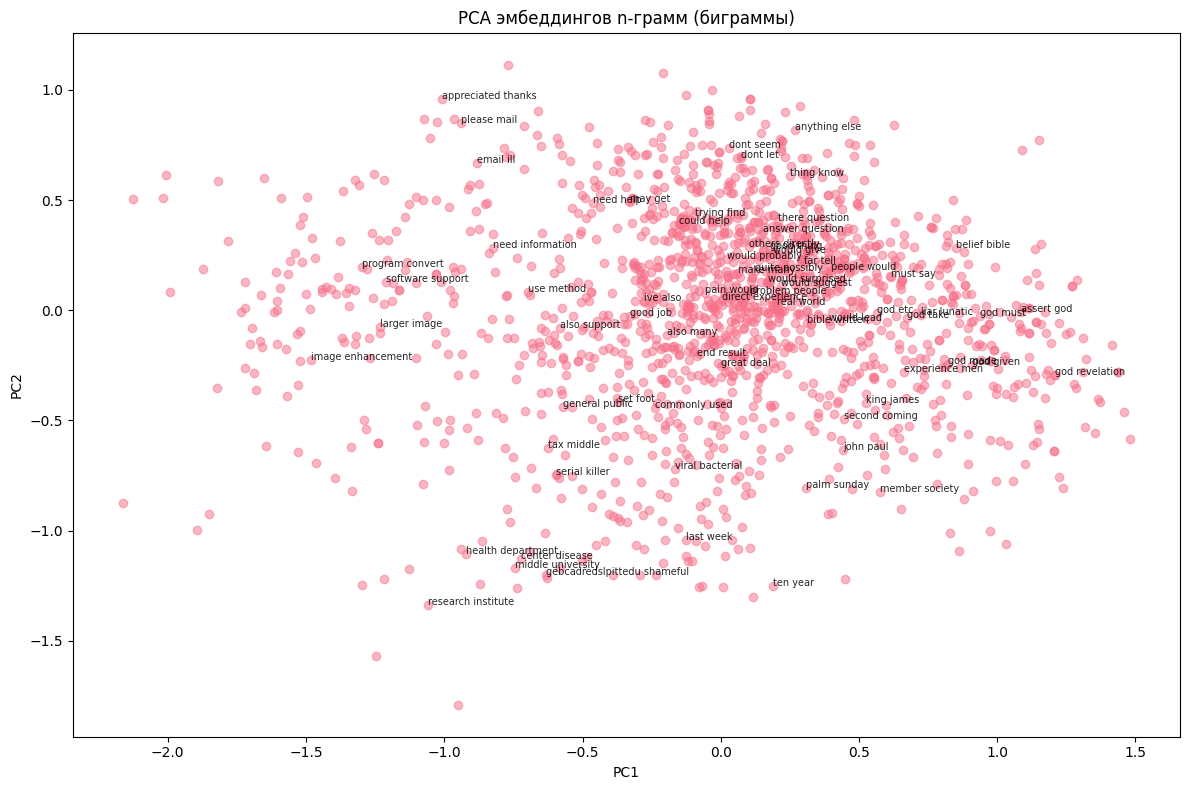

In [28]:
ngram_list = list(ngram_embeddings.keys())
ngram_matrix = np.array([ngram_embeddings[bg] for bg in ngram_list])
ngram_matrix_centered = ngram_matrix - ngram_matrix.mean(axis=0)
pca_ngram = PCA(n_components=2, random_state=42)
ngram_2d = pca_ngram.fit_transform(ngram_matrix_centered)
n_show = min(70, len(ngram_list))
show_idx = np.random.RandomState(42).choice(len(ngram_list), size=n_show, replace=False)
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(ngram_2d[:, 0], ngram_2d[:, 1], alpha=0.5)
for i in show_idx:
    ax.annotate(ngram_list[i], (ngram_2d[i, 0], ngram_2d[i, 1]), fontsize=7, alpha=0.85)
ax.set_title("PCA эмбеддингов n-грамм (биграммы)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

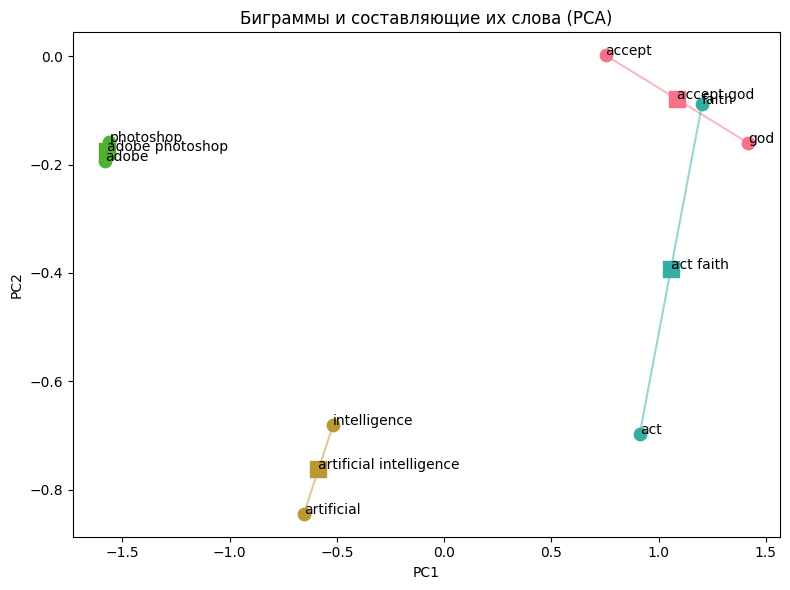

In [29]:
example_bigrams = [bg for bg in ["accept god", "artificial intelligence", "adobe photoshop", "act faith"] if bg in ngram_embeddings]
if len(example_bigrams) < 2:
    example_bigrams = ngram_list[:2]
all_vectors = []
all_labels = []
example_limits = []
for bg in example_bigrams:
    start = len(all_vectors)
    words = bg.split()
    for w in words:
        all_vectors.append(w2v_model.wv[w])
        all_labels.append(("word", w))
    all_vectors.append(ngram_embeddings[bg])
    all_labels.append(("ngram", bg))
    example_limits.append((start, len(all_vectors)))

X_ex = np.array(all_vectors)
X_ex_centered = X_ex - ngram_matrix.mean(axis=0)
coords = pca_ngram.transform(X_ex_centered)
fig, ax = plt.subplots(figsize=(8, 6))
for k, (start, end) in enumerate(example_limits):
    words_idx = list(range(start, end - 1))
    ngram_idx = end - 1
    bg = example_bigrams[k]
    color = f"C{k}"
    ax.scatter(coords[words_idx, 0], coords[words_idx, 1], c=color, s=80, zorder=2)
    ax.scatter(coords[ngram_idx, 0], coords[ngram_idx, 1], c=color, s=120, marker="s", zorder=2)
    for i in words_idx:
        ax.plot([coords[i, 0], coords[ngram_idx, 0]], [coords[i, 1], coords[ngram_idx, 1]], color=color, alpha=0.5, zorder=1)
        ax.annotate(all_labels[i][1], (coords[i, 0], coords[i, 1]), fontsize=10)
    ax.annotate(bg, (coords[ngram_idx, 0], coords[ngram_idx, 1]), fontsize=10)
ax.set_title("Биграммы и составляющие их слова (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

Биграммы кажутся осмысленными, посмотрим, так ли это с документами:

In [30]:
doc_embeddings = np.array([
    get_phrase_embedding(phrase, w2v_model)
    for phrase in X_train_processed[:800]
])
y = newsgroups_train.target[:800]


Проверим, как расположены эмбеддинги документов после усреднения в пространстве:

Объясненная дисперсия PCA для документов: 0.501


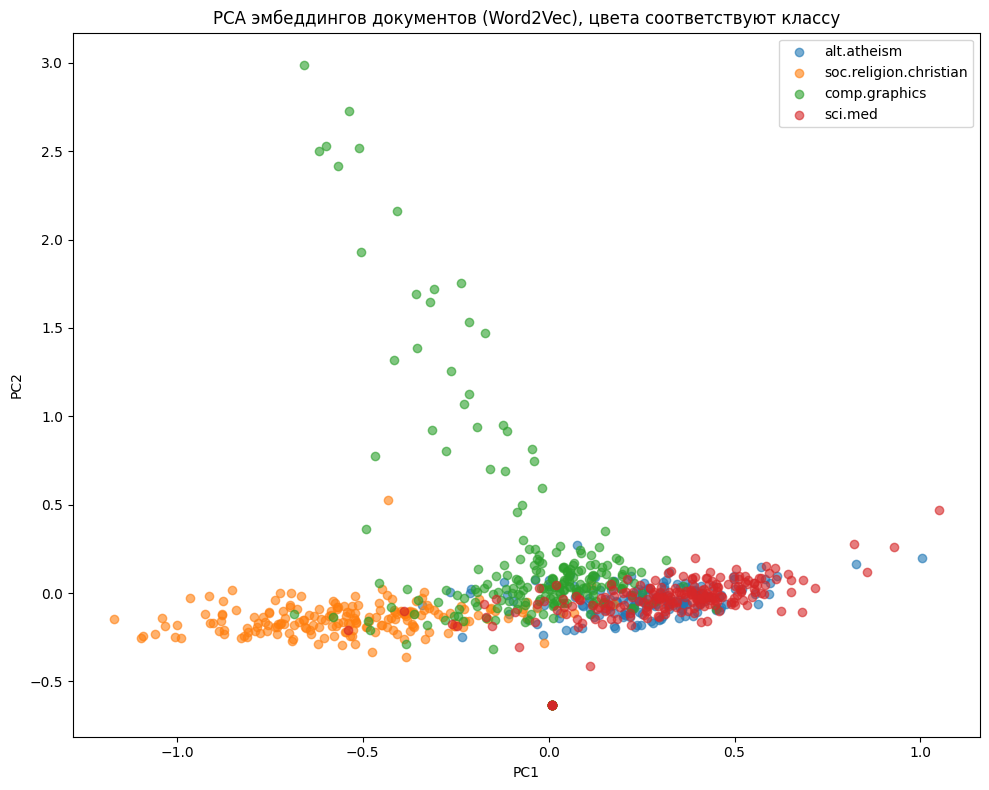

In [31]:
pca_docs = PCA(n_components=2, random_state=42)
doc_2d = pca_docs.fit_transform(doc_embeddings)

print(f"Объясненная дисперсия PCA для документов: {pca_docs.explained_variance_ratio_.sum():.3f}")

fig, ax = plt.subplots(figsize=(10, 8))

unique_labels = sorted(set(y))
colors = plt.cm.tab10.colors

for idx, label in enumerate(unique_labels):
    mask = (y == label)
    ax.scatter(
        doc_2d[mask, 0],
        doc_2d[mask, 1],
        alpha=0.6,
        color=colors[idx % len(colors)],
        label=categories[label],
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA эмбеддингов документов (Word2Vec), цвета соответствуют классу")
ax.legend()
plt.tight_layout()
plt.show()

Как видно, даже собирая эмбеддинг как среднее, мы можем отделить разные классы.

Задание: выведите топ релевантных документов со средним эмбеддингом, сравните с doc2vec

In [32]:
doc_embeddings_w2v = np.array([
    get_phrase_embedding(text, w2v_model)
    for text in X_train_processed[:800]
])

doc_embeddings_w2v_df = pd.DataFrame(
    doc_embeddings_w2v,
    index=list(range(len(doc_embeddings_w2v)))
)

query = "computer graphics"
query_vec_w2v = get_phrase_embedding(query, w2v_model)

res_w2v_df = most_similar(
    query_vec_w2v.reshape(1, -1),
    doc_embeddings_w2v_df,
    n=3
)

print("Query:", query)
print("\nТоп-3 по среднему Word2Vec embeddings:")

for rank, row in enumerate(res_w2v_df.itertuples(index=False), start=1):
    doc_id = int(row.document_id)
    score = float(row.cos_sim)
    
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[doc_id])

Query: computer graphics

Топ-3 по среднему Word2Vec embeddings:

#1 doc_id=486, cos_sim=0.8911
job opportunity serisystems engineering research institute kistkorea institute science technology looking resume following position need end june interested send resume cadcae lab floor system engineering research institute korea institute science technology yousunggu eoeundong daejon korea company system engineering research institute title senior research scientist job description depth knowledge working knowledge computer aided design working knowledge computer graphic working knowledge virtual reality skill required desirable knowledge data modeling virtual reality experience understanding clientserver architecture requirement phd job location daejon korea contact info chulho lim cadcae lab floor system engineering research institute korea institute science technology yousunggu eoeundong daejon korea

#2 doc_id=232, cos_sim=0.8730
sampe ncga university akron nasa lewis research center sp

In [33]:
query_words = preprocess_text(query).split()

if len(query_words) == 0:
    query_words = query.split()

query_vec_d2v = d2v_model.infer_vector(query_words)

document_embeddings_d2v_df = pd.DataFrame(
    [d2v_model.dv[i] for i in range(len(tagged_docs))],
    index=list(range(len(tagged_docs)))
)

res_d2v_df = most_similar(
    query_vec_d2v.reshape(1, -1),
    document_embeddings_d2v_df,
    n=3
)

print("Query:", query)
print("\nТоп-3 по Doc2Vec:")

for rank, row in enumerate(res_d2v_df.itertuples(index=False), start=1):
    doc_id = int(row.document_id)
    score = float(row.cos_sim)
    
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[doc_id])

Query: computer graphics

Топ-3 по Doc2Vec:

#1 doc_id=400, cos_sim=0.9337
archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april scene generatorsgeographical datamapsdata file dems digital elevation model dems digital elevation model well cartographic data huge available spectrumxeroxcom pubmap contact lee moore webster research center xerox corp voice arpa internet moorewbstxeroxcom check also ncgiaucsbedu pubdems nfotis many file also available cdrom selled usgs scale digital line graph dlg data contains data state price call visit office menlo park reston virginia usamaps data user service division bureau census also data cdrom tso standard format derived usgs map data call info bb drdobbs march defense mapping agency cooperation counterpart agency canada australia released digital chart world dcw chart consists gigabyte reasonable quality vector data distributed four cdroms includes coastline river road railrays a

In [34]:
compare_search = pd.DataFrame({
    "rank": [1, 2, 3],
    "avg_w2v_doc_id": res_w2v_df["document_id"].astype(int).values,
    "avg_w2v_score": res_w2v_df["cos_sim"].values,
    "doc2vec_doc_id": res_d2v_df["document_id"].astype(int).values,
    "doc2vec_score": res_d2v_df["cos_sim"].values,
})

compare_search

,rank,avg_w2v_doc_id,avg_w2v_score,doc2vec_doc_id,doc2vec_score
0,1,486,0.891122,400,0.933697
1,2,232,0.872957,768,0.922184
2,3,252,0.852655,716,0.868215


Результаты поиска отличаются: топ-3 документов у методов не совпадает. Потому что средний Word2Vec embedding представляет документ как усреднение векторов слов, а Doc2Vec обучает отдельные векторы документов.

Но! значения cosine similarity внутри каждого метода достаточно высокие.

## Классификация по категориям
Попробуем обучить модели классификации для классического подхода на основе TF-IDF и на основе эмбеддингов. 

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

df_train = pd.DataFrame({
    "text": X_train_processed,
    "target": newsgroups_train.target[:1000],
})
df_test = pd.DataFrame({
    "text": X_test_processed,
    "target": newsgroups_test.target[:500],
})
y_train = df_train["target"].values
y_test = df_test["target"].values

X_train_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in df_train["text"]])
X_test_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in df_test["text"]])

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(df_train["text"])
X_test_tfidf = tfidf.transform(df_test["text"])

In [36]:
lr_w2v = LogisticRegression(max_iter=500, random_state=42).fit(X_train_w2v, y_train)
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_w2v, y_train)
lr_tfidf = LogisticRegression(max_iter=500, random_state=42).fit(X_train_tfidf, y_train)
rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_tfidf, y_train)

target_names = [categories[i] for i in range(len(categories))]

def print_metrics(name: str, y_true, y_pred) -> None:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    print("%s: acc=%.3f  precision(macro)=%.3f  recall(macro)=%.3f" % (name, acc, prec, rec))
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


In [37]:

print("=== TF-IDF, LogisticRegression ===")
print_metrics("TF-IDF LR", y_test, lr_tfidf.predict(X_test_tfidf))

print("=== W2V (avg), LogisticRegression ===")
print_metrics("W2V LR", y_test, lr_w2v.predict(X_test_w2v))

=== TF-IDF, LogisticRegression ===
TF-IDF LR: acc=0.780  precision(macro)=0.781  recall(macro)=0.768
                        precision    recall  f1-score   support

           alt.atheism       0.78      0.48      0.59       107
soc.religion.christian       0.76      0.91      0.83       117
         comp.graphics       0.81      0.80      0.80       136
               sci.med       0.77      0.88      0.82       140

              accuracy                           0.78       500
             macro avg       0.78      0.77      0.76       500
          weighted avg       0.78      0.78      0.77       500

=== W2V (avg), LogisticRegression ===
W2V LR: acc=0.768  precision(macro)=0.765  recall(macro)=0.758
                        precision    recall  f1-score   support

           alt.atheism       0.71      0.51      0.60       107
soc.religion.christian       0.81      0.90      0.85       117
         comp.graphics       0.82      0.79      0.80       136
               sci.med    

In [38]:

print("=== TF-IDF, RandomForest ===")
print_metrics("TF-IDF RF", y_test, rf_tfidf.predict(X_test_tfidf))

print("=== W2V (avg), RandomForest ===")
print_metrics("W2V RF", y_test, rf_w2v.predict(X_test_w2v))

=== TF-IDF, RandomForest ===
TF-IDF RF: acc=0.682  precision(macro)=0.697  recall(macro)=0.672
                        precision    recall  f1-score   support

           alt.atheism       0.73      0.37      0.49       107
soc.religion.christian       0.60      0.90      0.72       117
         comp.graphics       0.76      0.60      0.67       136
               sci.med       0.70      0.82      0.76       140

              accuracy                           0.68       500
             macro avg       0.70      0.67      0.66       500
          weighted avg       0.70      0.68      0.67       500

=== W2V (avg), RandomForest ===
W2V RF: acc=0.752  precision(macro)=0.744  recall(macro)=0.747
                        precision    recall  f1-score   support

           alt.atheism       0.64      0.54      0.59       107
soc.religion.christian       0.78      0.92      0.85       117
         comp.graphics       0.82      0.75      0.78       136
               sci.med       0.74     

Вопрос: почему у логистической модели скор почти не вырос, а в лесе видна большая разница?

У логистической модели разница между TF-IDF и усреднёнными Word2Vec-эмбеддингами может быть небольшой, потому что логистическая регрессия сама по себе хорошо работает с разреженными TF-IDF-признаками, а лес - нет.

Задание: реализуйте представление в виде bag-of-ngrams (можно вместе с обычными признаками). Обучите классификатор на нем, сделайте выводы.

In [39]:
ngram_vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_ngram = ngram_vectorizer.fit_transform(df_train["text"])
X_test_ngram = ngram_vectorizer.transform(df_test["text"])

print("Train shape:", X_train_ngram.shape)
print("Test shape:", X_test_ngram.shape)
print("Размер словаря:", len(ngram_vectorizer.vocabulary_))

Train shape: (1000, 10000)
Test shape: (500, 10000)
Размер словаря: 10000


In [40]:
lr_ngram = LogisticRegression(
    max_iter=500,
    random_state=42
)

lr_ngram.fit(X_train_ngram, y_train)

print("Bag-of-ngrams, LogisticRegression")
print_metrics("Ngrams LR", y_test, lr_ngram.predict(X_test_ngram))

Bag-of-ngrams, LogisticRegression
Ngrams LR: acc=0.742  precision(macro)=0.743  recall(macro)=0.740
                        precision    recall  f1-score   support

           alt.atheism       0.72      0.64      0.68       107
soc.religion.christian       0.67      0.85      0.75       117
         comp.graphics       0.77      0.66      0.71       136
               sci.med       0.81      0.80      0.81       140

              accuracy                           0.74       500
             macro avg       0.74      0.74      0.74       500
          weighted avg       0.75      0.74      0.74       500



In [41]:
rf_ngram = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_ngram.fit(X_train_ngram, y_train)

print("Bag-of-ngrams, RandomForest")
print_metrics("Ngrams RF", y_test, rf_ngram.predict(X_test_ngram))

Bag-of-ngrams, RandomForest
Ngrams RF: acc=0.714  precision(macro)=0.724  recall(macro)=0.706
                        precision    recall  f1-score   support

           alt.atheism       0.73      0.43      0.54       107
soc.religion.christian       0.65      0.95      0.77       117
         comp.graphics       0.79      0.61      0.69       136
               sci.med       0.73      0.84      0.78       140

              accuracy                           0.71       500
             macro avg       0.72      0.71      0.69       500
          weighted avg       0.73      0.71      0.70       500



In [42]:
results = []

models = {
    "TF-IDF LR": (lr_tfidf, X_test_tfidf),
    "W2V LR": (lr_w2v, X_test_w2v),
    "Ngrams LR": (lr_ngram, X_test_ngram),
    "TF-IDF RF": (rf_tfidf, X_test_tfidf),
    "W2V RF": (rf_w2v, X_test_w2v),
    "Ngrams RF": (rf_ngram, X_test_ngram),
}

for name, (model, X_cur) in models.items():
    pred = model.predict(X_cur)
    
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_macro": precision_score(y_test, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, pred, average="macro", zero_division=0),
    })

pd.DataFrame(results).sort_values("accuracy", ascending=False)

,model,accuracy,precision_macro,recall_macro
0,TF-IDF LR,0.780,0.781118,0.767802
1,W2V LR,0.768,0.765249,0.758483
4,W2V RF,0.752,0.743924,0.746640
2,Ngrams LR,0.742,0.742679,0.740331
5,Ngrams RF,0.714,0.724308,0.706158
3,TF-IDF RF,0.682,0.697237,0.672071


Лучшей моделью оказалась TF-IDF + LogisticRegression.

Для RandomForest результат на n-граммах оказался выше, чем на TF-IDF, но ниже, чем на W2V-эмбеддингах. Можно объяснить тем, что RandomForest хуже работает с высокоразмерными разреженными текстовыми признаками, а плотные W2V-векторы для него удобнее.

Таким образом, для линейной модели лучше всего подошел TF-IDF, а для RandomForest - плотные Word2Vec-эмбеддинги.